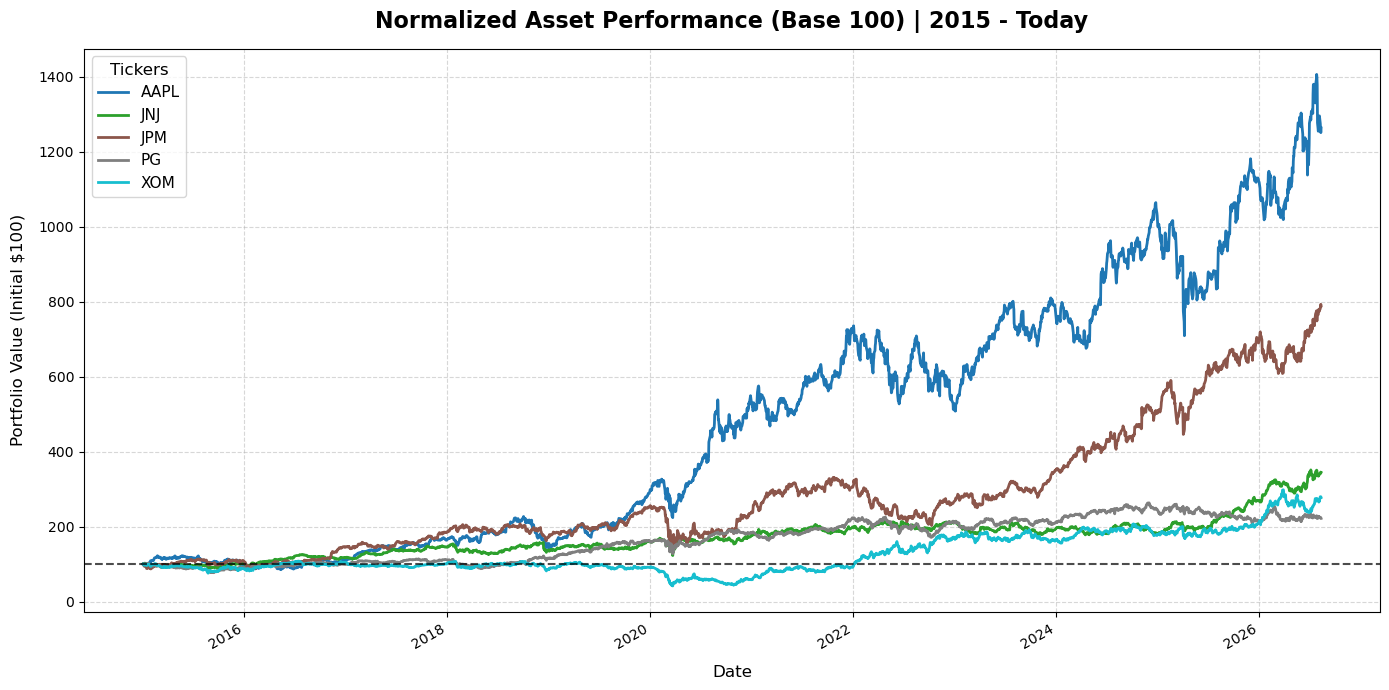

=== PORTFOLIO QUANT SUMMARY ===

[Equal-Weight Portfolio]
Annualized Return: 16.22%
Maximum Drawdown:  -35.22%

[Risk-Tilted (Inverse Volatility) Portfolio]
Weights:
Ticker
AAPL    16.06%
JNJ     25.23%
JPM     17.15%
PG      24.75%
XOM     16.81%
dtype: object
Annualized Return: 15.23%
Maximum Drawdown:  -33.46%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime

# ==========================================
# 1. CONSTANTS (Project Settings)
# ==========================================
TICKERS = ["AAPL", "JNJ", "XOM", "JPM", "PG"]
START_DATE = "2015-01-01"
END_DATE = datetime.date.today()
TRADING_DAYS = 252

# ==========================================
# 2. DATA PIPELINE
# ==========================================
def get_clean_data(tickers, start, end):
    data = yf.download(tickers, start=start, end=end, progress=False)["Close"]
    data = data.dropna()

    assert data.index.is_monotonic_increasing, "Σφάλμα: μη ταξινομημένα δεδομένα!"
    assert data.isna().sum().sum() == 0, "Σφάλμα: υπάρχουν NaN!"

    return data


# ==========================================
# Normalization & Οπτική Σύγκριση (Base=100)
# ==========================================
def plot_normalized_data(data: pd.DataFrame):
    normalized_data = (data / data.iloc[0]) * 100
    ax = normalized_data.plot(figsize=(14, 7), linewidth=2, colormap="tab10")
    ax.axhline(100, color="black", linestyle="--", linewidth=1.5, alpha=0.7)
    plt.title("Normalized Asset Performance (Base 100) | 2015 - Today",
              fontsize=16, fontweight="bold", pad=15)
    plt.xlabel("Date", fontsize=12, labelpad=10)
    plt.ylabel("Portfolio Value (Initial $100)", fontsize=12, labelpad=10)
    plt.legend(title="Tickers", fontsize=11, title_fontsize=12, loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


# ==========================================
# Equal-Weight Portfolio
# ==========================================
def build_equal_weight_portfolio(data):
    daily_simple_returns = data.pct_change().dropna()
    n_assets = len(data.columns)
    weights_eq = pd.Series(1 / n_assets, index=data.columns)
    portfolio_returns_eq = (daily_simple_returns * weights_eq).sum(axis=1)
    return daily_simple_returns, portfolio_returns_eq


# ==========================================
# Risk-Tilted Portfolio (Inverse Volatility)
# ==========================================
def build_risk_tilted_portfolio(daily_simple_returns):
    annualized_vol = daily_simple_returns.std() * np.sqrt(TRADING_DAYS)
    inv_vol = 1 / annualized_vol
    weights_risk = inv_vol / inv_vol.sum()
    portfolio_returns_risk = (daily_simple_returns * weights_risk).sum(axis=1)
    return weights_risk, portfolio_returns_risk


# ==========================================
# Portfolio Drawdown Analysis
# ==========================================
def calculate_drawdowns(portfolio_returns):
    wealth_index = (1 + portfolio_returns).cumprod()
    previous_peaks = wealth_index.cummax()
    drawdowns = (wealth_index - previous_peaks) / previous_peaks
    max_drawdown = drawdowns.min()
    return drawdowns, max_drawdown


# ==========================================
# Quant Summary
# ==========================================
def print_quant_summary(returns_eq, max_dd_eq, returns_risk, max_dd_risk, weights_risk):
    ann_ret_eq = returns_eq.mean() * TRADING_DAYS
    ann_ret_risk = returns_risk.mean() * TRADING_DAYS

    print("=== PORTFOLIO QUANT SUMMARY ===")
    print("\n[Equal-Weight Portfolio]")
    print(f"Annualized Return: {ann_ret_eq * 100:.2f}%")
    print(f"Maximum Drawdown:  {max_dd_eq * 100:.2f}%")

    print("\n[Risk-Tilted (Inverse Volatility) Portfolio]")
    print("Weights:")
    print(weights_risk.map("{:.2%}".format))
    print(f"Annualized Return: {ann_ret_risk * 100:.2f}%")
    print(f"Maximum Drawdown:  {max_dd_risk * 100:.2f}%")
    print("===============================")


# ==========================================
# 3. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":

    prices = get_clean_data(TICKERS, START_DATE, END_DATE)
    plot_normalized_data(prices)

    daily_returns, portfolio_eq = build_equal_weight_portfolio(prices)
    weights_risk, portfolio_risk = build_risk_tilted_portfolio(daily_returns)

    drawdowns_eq, max_dd_eq = calculate_drawdowns(portfolio_eq)
    drawdowns_risk, max_dd_risk = calculate_drawdowns(portfolio_risk)

    print_quant_summary(portfolio_eq, max_dd_eq, portfolio_risk, max_dd_risk, weights_risk)